# Assignment 3 — Part 2: Hierarchical Risk Parity (HRP)
## Person 3 Deliverables: Data Pipeline, Clustering & Dendrogram

This notebook implements:
1. **Data Fetching**: 5Y adjusted close prices for 12 NSE stocks
2. **Daily Returns**: Compute and split into train (4Y) / test (1Y)
3. **Correlation & Distance Matrix**: From train data
4. **Hierarchical Clustering**: Ward and Single linkage comparison
5. **Viz 2**: HRP Dendrogram with interpreted cluster labels
6. **Cluster Interpretation Notes** for the report
7. **Outputs for Person 4**: Linkage matrix, leaf order, daily returns CSVs

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_DIR = Path('..').resolve()
DATA_RAW = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'figures'

for d in [DATA_RAW, DATA_PROCESSED, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Tickers
TICKERS = [
    'TCS.NS', 'INFY.NS', 'HCLTECH.NS',
    'TATASTEEL.NS', 'HINDALCO.NS', 'JINDALSTEL.NS',
    'HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS',
    'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS'
]

# Short names for display
SHORT_NAMES = {
    'TCS.NS': 'TCS', 'INFY.NS': 'INFY', 'HCLTECH.NS': 'HCLTECH',
    'TATASTEEL.NS': 'TATASTEEL', 'HINDALCO.NS': 'HINDALCO', 'JINDALSTEL.NS': 'JINDALSTEL',
    'HDFCBANK.NS': 'HDFCBANK', 'ICICIBANK.NS': 'ICICIBANK', 'KOTAKBANK.NS': 'KOTAKBANK',
    'HINDUNILVR.NS': 'HINDUNILVR', 'ITC.NS': 'ITC', 'NESTLEIND.NS': 'NESTLEIND'
}

print('Setup complete.')

Setup complete.


---
## 1. Data Fetching — 5Y Adjusted Close Prices

In [3]:
# Fetch 5 years of adjusted close data
end_date = datetime(2025, 1, 1) # exclusive
start_date = datetime(2020, 1, 1)

print(f'Fetching data from {start_date} to {end_date}')

raw_data = yf.download(
    TICKERS,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True
)

# Extract Close prices (auto_adjust=True means these are already adjusted)
if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data['Close']
else:
    prices = raw_data[['Close']]

# Rename columns to short names
prices.columns = [SHORT_NAMES.get(c, c) for c in prices.columns]

# Drop any rows with all NaN, forward fill small gaps
prices = prices.dropna(how='all').ffill()

# Save raw prices
prices.to_csv(DATA_RAW / 'adjusted_close_daily.csv')

print(f'\nPrice data shape: {prices.shape}')
print(f'Date range: {prices.index.min()} to {prices.index.max()}')
print(f'Stocks: {list(prices.columns)}')
prices.tail()

Fetching data from 2020-01-01 00:00:00 to 2025-01-01 00:00:00


[*********************100%***********************]  12 of 12 completed


Price data shape: (1238, 12)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Stocks: ['HCLTECH', 'HDFCBANK', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INFY', 'ITC', 'JINDALSTEL', 'KOTAKBANK', 'NESTLEIND', 'TATASTEEL', 'TCS']


,HCLTECH,HDFCBANK,HINDALCO,HINDUNILVR,ICICIBANK,INFY,ITC,JINDALSTEL,KOTAKBANK,NESTLEIND,TATASTEEL,TCS
Date,,,,,,,,,,,,
2024-12-24,1814.317017,887.059631,622.882080,2293.217529,1287.317017,1854.176880,436.200623,940.833557,349.407135,1066.192871,137.180862,3966.892090
2024-12-26,1817.951538,883.433655,624.172607,2290.468262,1287.416138,1852.574341,434.833099,939.486206,350.156281,1057.925903,137.161316,3957.020752
2024-12-27,1809.582520,887.133667,612.905273,2298.814209,1297.538208,1861.655518,436.337372,921.721436,351.574677,1065.651611,135.744370,3952.987305
2024-12-30,1844.922852,877.094360,596.723877,2301.023438,1284.736938,1851.214478,434.878693,916.481873,347.739075,1062.846680,133.760635,3947.244873
2024-12-31,1833.876099,874.603027,598.064087,2284.675293,1271.836426,1825.961792,440.941437,928.857361,356.798615,1067.841309,134.903961,3886.500244


---
## 2. Daily Returns & Train/Test Split

In [4]:
# Compute daily returns
daily_returns = prices.pct_change().dropna()

print(f'Daily returns shape: {daily_returns.shape}')
print(f'Date range: {daily_returns.index[0].date()} to {daily_returns.index[-1].date()}')

# Train/test split: first 4 years = train, last 1 year = test
split_date = datetime(2024, 1, 1)
print(f'\nSplit date: {split_date.date()}')

returns_train = daily_returns[daily_returns.index < split_date]
returns_test = daily_returns[daily_returns.index >= split_date]

print(f'Train: {returns_train.shape[0]} days ({returns_train.index[0].date()} to {returns_train.index[-1].date()})')
print(f'Test:  {returns_test.shape[0]} days ({returns_test.index[0].date()} to {returns_test.index[-1].date()})')

# Save CSVs
returns_train.to_csv(DATA_PROCESSED / 'daily_returns_train.csv')
returns_test.to_csv(DATA_PROCESSED / 'daily_returns_test.csv')
daily_returns.to_csv(DATA_PROCESSED / 'daily_returns.csv')

print('\nSaved: daily_returns_train.csv, daily_returns_test.csv, daily_returns.csv')

# """ Daily returns shape: (1486, 12)
# Date range: 2020-01-02 to 2025-12-31
# Split date: 2025-01-01
# Train: 1237 days (2020-01-02 to 2024-12-31)
# Test:  249 days (2025-01-01 to 2025-12-31)
# """

Daily returns shape: (1237, 12)
Date range: 2020-01-02 to 2024-12-31

Split date: 2024-01-01
Train: 991 days (2020-01-02 to 2023-12-29)
Test:  246 days (2024-01-01 to 2024-12-31)

Saved: daily_returns_train.csv, daily_returns_test.csv, daily_returns.csv


In [5]:
# Quick sanity check — summary statistics of train returns
train_stats = returns_train.describe().T
train_stats['annualized_vol'] = returns_train.std() * np.sqrt(252)
train_stats['annualized_return'] = returns_train.mean() * 252
print('Train Data — Annualized Return & Volatility:')
train_stats[['annualized_return', 'annualized_vol']].round(4)

Train Data — Annualized Return & Volatility:


,annualized_return,annualized_vol
HCLTECH,0.3167,0.2894
HDFCBANK,0.1210,0.2836
HINDALCO,0.3694,0.4339
HINDUNILVR,0.1270,0.2470
ICICIBANK,0.2197,0.3393
INFY,0.2532,0.2897
ITC,0.2549,0.2733
JINDALSTEL,0.5101,0.5003
KOTAKBANK,0.0810,0.3070
NESTLEIND,0.1873,0.2318


---
## 3. Correlation Matrix (Train Data)

Correlation Matrix (Train Data):
            HCLTECH  HDFCBANK  HINDALCO  HINDUNILVR  ICICIBANK   INFY    ITC  \
HCLTECH       1.000     0.329     0.424       0.331      0.318  0.688  0.225   
HDFCBANK      0.329     1.000     0.425       0.266      0.669  0.398  0.308   
HINDALCO      0.424     0.425     1.000       0.233      0.499  0.395  0.337   
HINDUNILVR    0.331     0.266     0.233       1.000      0.287  0.355  0.278   
ICICIBANK     0.318     0.669     0.499       0.287      1.000  0.401  0.343   
INFY          0.688     0.398     0.395       0.355      0.401  1.000  0.254   
ITC           0.225     0.308     0.337       0.278      0.343  0.254  1.000   
JINDALSTEL    0.397     0.417     0.710       0.225      0.478  0.365  0.307   
KOTAKBANK     0.292     0.646     0.358       0.309      0.608  0.350  0.315   
NESTLEIND     0.339     0.276     0.274       0.608      0.274  0.314  0.207   
TATASTEEL     0.354     0.382     0.753       0.184      0.458  0.339  0.353   
TCS    

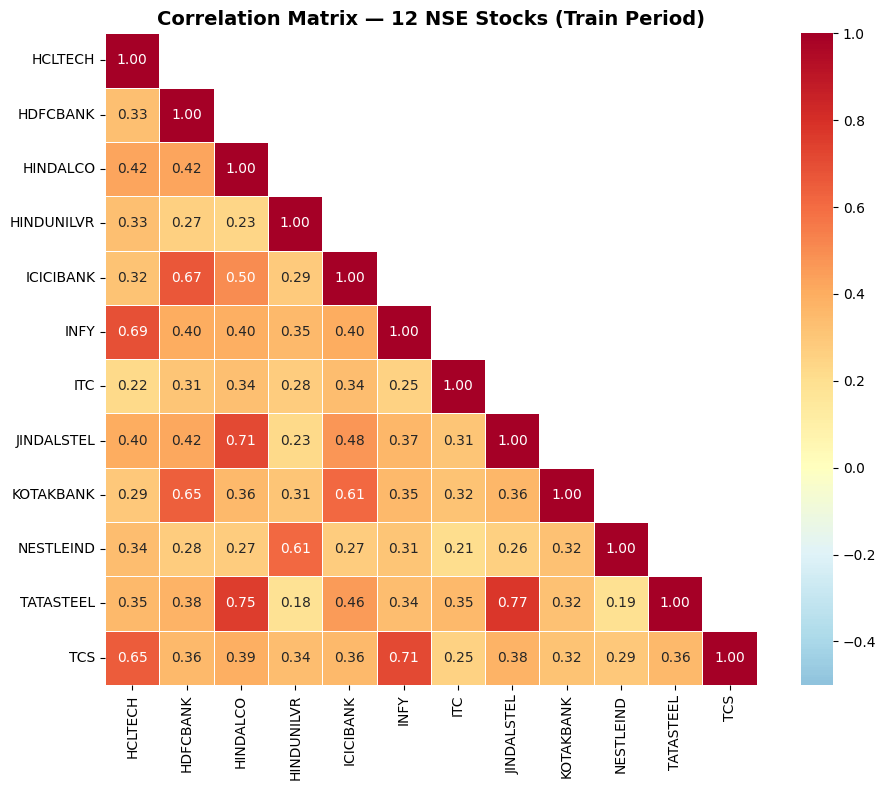

In [6]:
# Compute correlation matrix on training data
corr_matrix = returns_train.corr()

print('Correlation Matrix (Train Data):')
print(corr_matrix.round(3))

# Save
corr_matrix.to_csv(DATA_PROCESSED / 'correlation_matrix_train.csv')

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-0.5, vmax=1.0, square=True,
            linewidths=0.5,)
plt.title('Correlation Matrix — 12 NSE Stocks (Train Period)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix_train.png', dpi=150, bbox_inches='tight')
print('Saved: correlation_matrix_train.png')
plt.show()

---
## 4. Distance Matrix

Convert the correlation matrix to a proper distance metric using:

$$D_{ij} = \sqrt{\frac{1}{2}(1 - \rho_{ij})}$$

This maps correlations from [-1, 1] to distances in [0, 1], where:
- Perfectly correlated stocks → distance = 0
- Uncorrelated stocks → distance ≈ 0.707
- Perfectly anti-correlated stocks → distance = 1

Distance Matrix:
            HCLTECH  HDFCBANK  HINDALCO  HINDUNILVR  ICICIBANK   INFY    ITC  \
HCLTECH       0.000     0.579     0.537       0.578      0.584  0.395  0.623   
HDFCBANK      0.579     0.000     0.536       0.606      0.407  0.548  0.588   
HINDALCO      0.537     0.536     0.000       0.619      0.501  0.550  0.576   
HINDUNILVR    0.578     0.606     0.619       0.000      0.597  0.568  0.601   
ICICIBANK     0.584     0.407     0.501       0.597      0.000  0.547  0.573   
INFY          0.395     0.548     0.550       0.568      0.547  0.000  0.611   
ITC           0.623     0.588     0.576       0.601      0.573  0.611  0.000   
JINDALSTEL    0.549     0.540     0.381       0.622      0.511  0.563  0.589   
KOTAKBANK     0.595     0.421     0.567       0.588      0.443  0.570  0.585   
NESTLEIND     0.575     0.602     0.602       0.443      0.603  0.586  0.630   
TATASTEEL     0.568     0.556     0.352       0.639      0.521  0.575  0.569   
TCS           0.419    

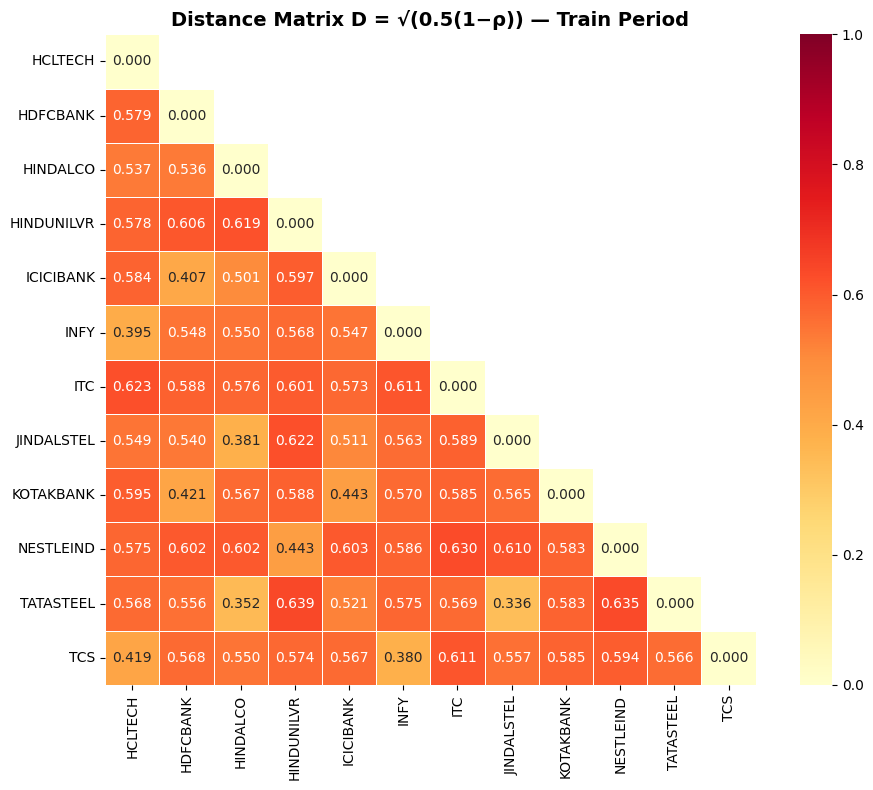

Saved: distance_matrix_train.png


In [7]:
# Compute distance matrix
dist_matrix = np.sqrt(0.5 * (1 - corr_matrix))

print('Distance Matrix:')
print(dist_matrix.round(3))

# Save
dist_matrix.to_csv(DATA_PROCESSED / 'distance_matrix_train.csv')

# Visualize distance matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(dist_matrix, dtype=bool), k=1)
sns.heatmap(dist_matrix, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1.0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Distance Matrix D = √(0.5(1−ρ)) — Train Period', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distance_matrix_train.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: distance_matrix_train.png')

---
## 5. Hierarchical Clustering

We try both **Ward** and **Single** linkage methods and compare the resulting dendrograms to select the one that produces cleaner, more interpretable clusters.  
In theory, we use **single linkage** for heirarchial clustering.

In [8]:
# Convert distance matrix to condensed form for scipy linkage
# Ensure the distance matrix is symmetric and has zero diagonal
dist_array = dist_matrix.values.copy()
np.fill_diagonal(dist_array, 0)
condensed_dist = squareform(dist_array) # convert distance matrix into a flat vector

# Ward linkage
linkage_ward = linkage(condensed_dist, method='ward')

# Single linkage
linkage_single = linkage(condensed_dist, method='single')

print('Linkage matrices computed.')
print(f'Ward linkage shape: {linkage_ward.shape}')
print(f'Single linkage shape: {linkage_single.shape}')

Linkage matrices computed.
Ward linkage shape: (11, 4)
Single linkage shape: (11, 4)


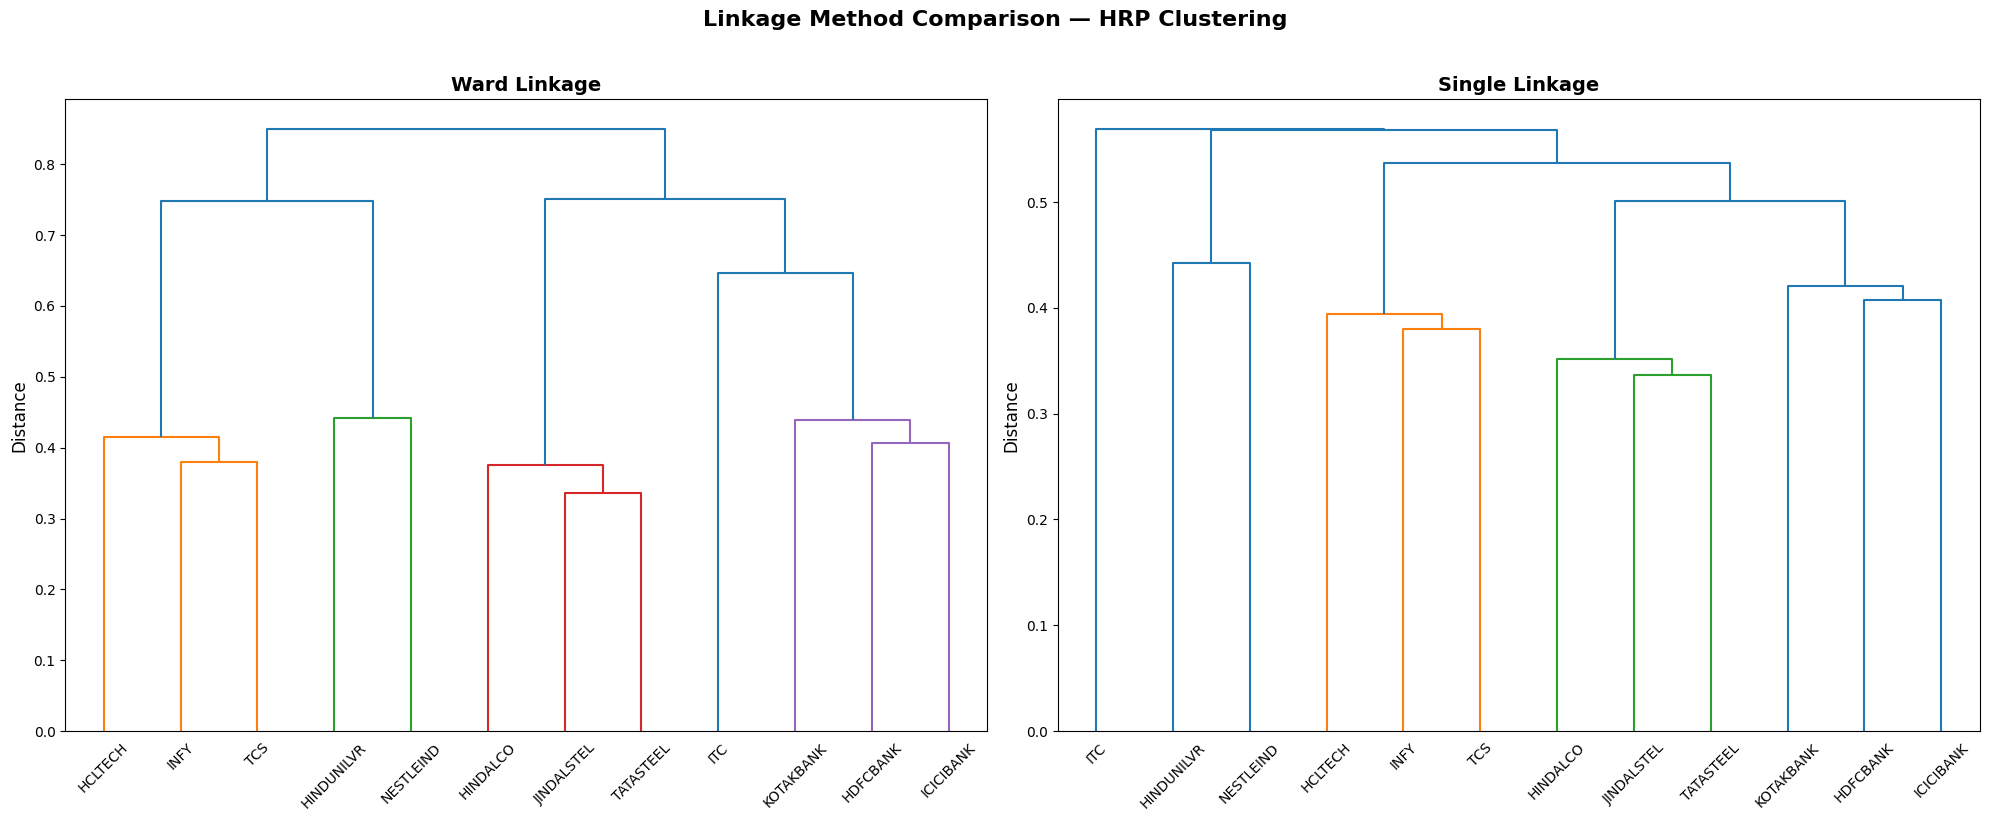


Ward linkage typically produces more balanced, compact clusters.
Single linkage tends to produce chaining effects (long thin clusters).


Selecting Single linkage for the final HRP implementation (theoretically accurate HRP).


In [9]:
# Compare both dendrograms side by side
stock_names = list(corr_matrix.columns)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Ward
axes[0].set_title('Ward Linkage', fontsize=14, fontweight='bold')
dendrogram(linkage_ward, labels=stock_names, ax=axes[0],
           leaf_rotation=45, leaf_font_size=10)
axes[0].set_ylabel('Distance', fontsize=12)
axes[0].set_xlabel('')

# Single
axes[1].set_title('Single Linkage', fontsize=14, fontweight='bold')
dendrogram(linkage_single, labels=stock_names, ax=axes[1],
           leaf_rotation=45, leaf_font_size=10)
axes[1].set_ylabel('Distance', fontsize=12)
axes[1].set_xlabel('')

plt.suptitle('Linkage Method Comparison — HRP Clustering', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'linkage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nWard linkage typically produces more balanced, compact clusters.')
print('Single linkage tends to produce chaining effects (long thin clusters).')
print('\n\nSelecting Single linkage for the final HRP implementation (theoretically accurate HRP).')

In [10]:
# Select Ward linkage as the final choice
linkage_matrix = linkage_single

# Extract the leaf order from the dendrogram (quasi-diagonalization order)
dendro_info = dendrogram(linkage_matrix, labels=stock_names, no_plot=True)
leaf_order = dendro_info['leaves']
leaf_labels = [stock_names[i] for i in leaf_order]

print('Cluster Leaf Order (for quasi-diagonalization):')
print(f'Indices: {leaf_order}')
print(f'Labels:  {leaf_labels}')

# Save linkage matrix and leaf order
np.save(DATA_PROCESSED / 'linkage_matrix_single.npy', linkage_matrix)
pd.DataFrame({'leaf_index': leaf_order, 'stock': leaf_labels}).to_csv(
    DATA_PROCESSED / 'leaf_order.csv', index=False)

print('\nSaved: linkage_matrix_single.npy, leaf_order.csv')

Cluster Leaf Order (for quasi-diagonalization):
Indices: [6, 3, 9, 0, 5, 11, 2, 7, 10, 8, 1, 4]
Labels:  ['ITC', 'HINDUNILVR', 'NESTLEIND', 'HCLTECH', 'INFY', 'TCS', 'HINDALCO', 'JINDALSTEL', 'TATASTEEL', 'KOTAKBANK', 'HDFCBANK', 'ICICIBANK']

Saved: linkage_matrix_single.npy, leaf_order.csv


---
## 6. Viz 2 — HRP Dendrogram with Cluster Interpretation

The dendrogram is labeled with:
- Ticker names on the x-axis
- Cluster interpretation annotations (not just sector labels)
- Color-coded clusters
- Distance thresholds shown

In [11]:
# Identify clusters using a distance threshold
# We use fcluster to cut the dendrogram and find natural groupings

distance_thresholds = [0.4, 0.45, 0.5, 0.55]

for thresh in distance_thresholds:
    clusters = fcluster(linkage_matrix, t=thresh, criterion='distance')
    cluster_df = pd.DataFrame({'Stock': stock_names, 'Cluster': clusters})
    
    print(f'\n--- Distance Threshold = {thresh:.2f} ---')
    
    for c in sorted(cluster_df['Cluster'].unique()):
        members = cluster_df[cluster_df['Cluster'] == c]['Stock'].tolist()
        print(f'  Cluster {c}: {members}')


--- Distance Threshold = 0.40 ---
  Cluster 1: ['HINDUNILVR']
  Cluster 2: ['NESTLEIND']
  Cluster 3: ['HCLTECH', 'INFY', 'TCS']
  Cluster 4: ['HINDALCO', 'JINDALSTEL', 'TATASTEEL']
  Cluster 5: ['HDFCBANK']
  Cluster 6: ['ICICIBANK']
  Cluster 7: ['KOTAKBANK']
  Cluster 8: ['ITC']

--- Distance Threshold = 0.45 ---
  Cluster 1: ['HINDUNILVR', 'NESTLEIND']
  Cluster 2: ['HCLTECH', 'INFY', 'TCS']
  Cluster 3: ['HINDALCO', 'JINDALSTEL', 'TATASTEEL']
  Cluster 4: ['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']
  Cluster 5: ['ITC']

--- Distance Threshold = 0.50 ---
  Cluster 1: ['HINDUNILVR', 'NESTLEIND']
  Cluster 2: ['HCLTECH', 'INFY', 'TCS']
  Cluster 3: ['HINDALCO', 'JINDALSTEL', 'TATASTEEL']
  Cluster 4: ['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']
  Cluster 5: ['ITC']

--- Distance Threshold = 0.55 ---
  Cluster 1: ['HINDUNILVR', 'NESTLEIND']
  Cluster 2: ['HCLTECH', 'HDFCBANK', 'HINDALCO', 'ICICIBANK', 'INFY', 'JINDALSTEL', 'KOTAKBANK', 'TATASTEEL', 'TCS']
  Cluster 3: ['ITC']


Threshold = 0.45 to 0.50 seems like a sweet spot  

We get evident groups-  

1. FMCG: HINDUNILVR, NESTLEIND

2. IT: HCLTECH, INFY, TCS

3. Metals: HINDALCO, JINDALSTEL, TATASTEEL

4. Banks: HDFCBANK, ICICIBANK, KOTAKBANK

5. ITC standalone

In [12]:
# Use distance threshold = 0.5 (approx. 0.5 correlation)
distance_threshold_final = 0.5

clusters_final = fcluster(
    linkage_matrix,
    t=distance_threshold_final,
    criterion='distance'
)

cluster_assignment = pd.DataFrame({
    'Stock': stock_names,
    'Cluster': clusters_final
})

unique_clusters = sorted(cluster_assignment['Cluster'].unique())

base_colors = [
    '#e74c3c',  # Red
    '#3498db',  # Blue
    '#2ecc71',  # Green
    '#f39c12',  # Orange
    '#9b59b6',  # Purple
    '#1abc9c',  # Teal
    '#34495e',  # Dark blue
    '#e67e22',  # Dark orange
]

cluster_colors = {
    cluster: base_colors[i % len(base_colors)]
    for i, cluster in enumerate(unique_clusters)
}

print(f'Final Cluster Assignments (Distance Threshold = {distance_threshold_final}):')
for c in unique_clusters:
    members = cluster_assignment[
        cluster_assignment['Cluster'] == c
    ]['Stock'].tolist()
    print(f'  Cluster {c}: {members}')

Final Cluster Assignments (Distance Threshold = 0.5):
  Cluster 1: ['HINDUNILVR', 'NESTLEIND']
  Cluster 2: ['HCLTECH', 'INFY', 'TCS']
  Cluster 3: ['HINDALCO', 'JINDALSTEL', 'TATASTEEL']
  Cluster 4: ['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']
  Cluster 5: ['ITC']


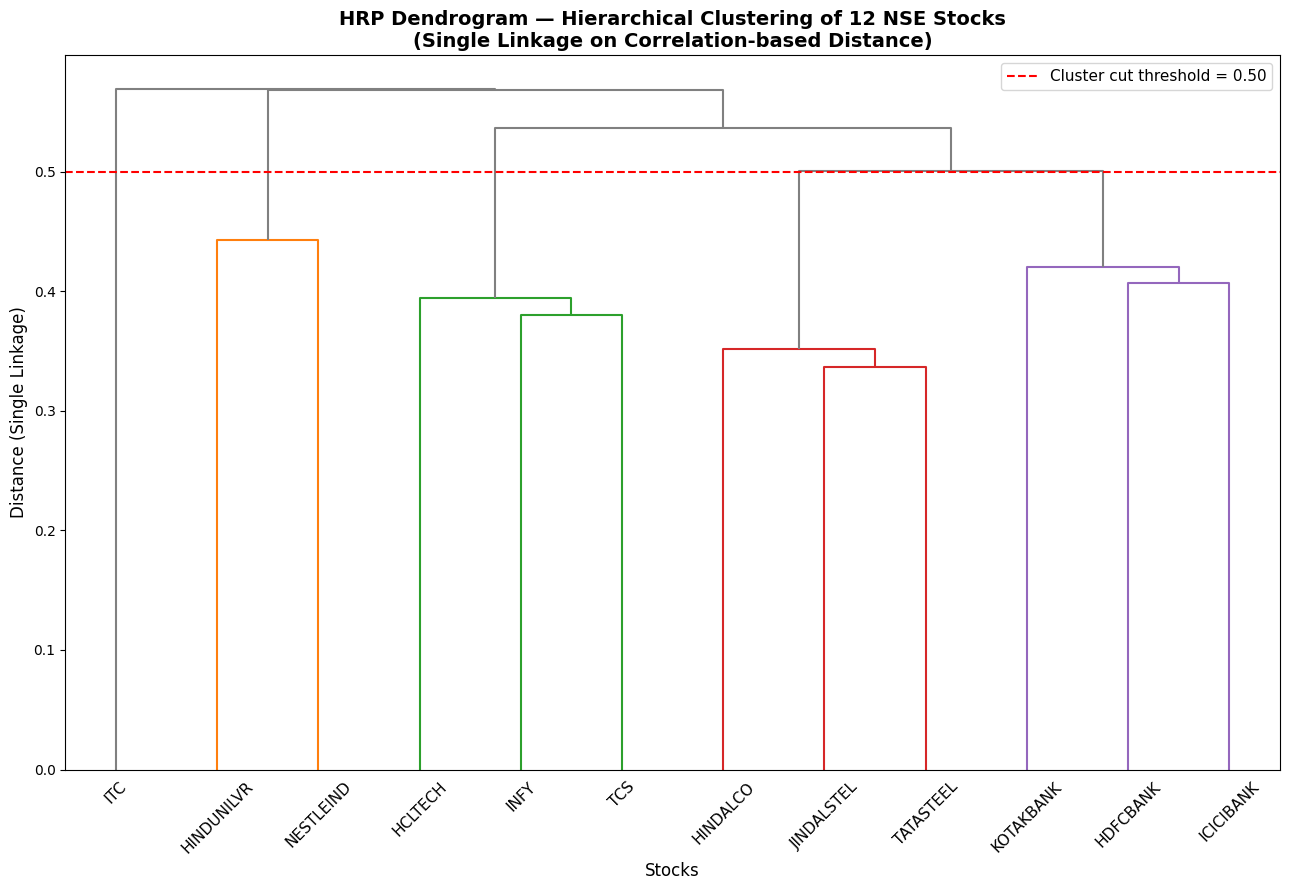

Saved: hrp_dendrogram_single.png


In [15]:
# Build the main dendrogram — Viz 2 (Single Linkage)

fig, ax = plt.subplots(figsize=(13, 9))

# Fixed distance threshold (~ correlation 0.5)
distance_threshold_final = 0.5

dendro = dendrogram(
    linkage_matrix,          # MUST be single linkage matrix
    labels=stock_names,
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=11,
    color_threshold=distance_threshold_final,
    above_threshold_color='grey'
)

# Add horizontal cut line
ax.axhline(
    y=distance_threshold_final,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Cluster cut threshold = {distance_threshold_final:.2f}'
)

ax.set_title(
    'HRP Dendrogram — Hierarchical Clustering of 12 NSE Stocks\n'
    '(Single Linkage on Correlation-based Distance)',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel('Distance (Single Linkage)', fontsize=12)
ax.set_xlabel('Stocks', fontsize=12)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hrp_dendrogram_single.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: hrp_dendrogram_single.png')

In [16]:
# Build the annotated dendrogram with cluster labels — FINAL Viz 2

# First, let's understand the cluster composition to write proper labels
print('Cluster Composition Analysis:')
print('=' * 60)

for c in sorted(cluster_assignment['Cluster'].unique()):
    members = cluster_assignment[cluster_assignment['Cluster'] == c]['Stock'].tolist()
    
    # Compute intra-cluster correlation
    if len(members) > 1:
        intra_corr = corr_matrix.loc[members, members]
        # Average off-diagonal correlation
        mask_offdiag = ~np.eye(len(members), dtype=bool)
        avg_corr = intra_corr.values[mask_offdiag].mean()
    else:
        avg_corr = 1.0
    
    # Compute cluster volatility stats
    cluster_vols = (returns_train[members].std() * np.sqrt(252)).round(4)
    
    print(f'\nCluster {c}: {members}')
    print(f'  Avg intra-cluster correlation: {avg_corr:.3f}')
    print('  Annualized volatilities:')
    for s, v in cluster_vols.items():
        print(f'    {s}: {v:.1%}')

Cluster Composition Analysis:

Cluster 1: ['HINDUNILVR', 'NESTLEIND']
  Avg intra-cluster correlation: 0.608
  Annualized volatilities:
    HINDUNILVR: 24.7%
    NESTLEIND: 23.2%

Cluster 2: ['HCLTECH', 'INFY', 'TCS']
  Avg intra-cluster correlation: 0.683
  Annualized volatilities:
    HCLTECH: 28.9%
    INFY: 29.0%
    TCS: 25.2%

Cluster 3: ['HINDALCO', 'JINDALSTEL', 'TATASTEEL']
  Avg intra-cluster correlation: 0.745
  Annualized volatilities:
    HINDALCO: 43.4%
    JINDALSTEL: 50.0%
    TATASTEEL: 39.3%

Cluster 4: ['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']
  Avg intra-cluster correlation: 0.641
  Annualized volatilities:
    HDFCBANK: 28.4%
    ICICIBANK: 33.9%
    KOTAKBANK: 30.7%

Cluster 5: ['ITC']
  Avg intra-cluster correlation: 1.000
  Annualized volatilities:
    ITC: 27.3%


In [17]:
# Cluster interpretation using statistical properties + structural cohesion

def get_cluster_label(cluster_id, members, returns_train):
    """
    Generate interpretive cluster label based on:
    - Annualized volatility
    - Average pairwise correlation (cohesion)
    - Structural co-movement patterns
    """
    
    cluster_returns = returns_train[members]
    
    # Annualized volatility
    vols = cluster_returns.std() * np.sqrt(252)
    avg_vol = vols.mean()
    
    # Annualized return
    avg_ret = (cluster_returns.mean() * 252).mean()
    
    # Intra-cluster average correlation
    corr_sub = cluster_returns.corr()
    upper_vals = corr_sub.where(
        np.triu(np.ones(corr_sub.shape), k=1).astype(bool)
    )
    avg_corr = upper_vals.stack().mean()
    
    # Volatility-based regime labeling
    if avg_vol > 0.35:
        vol_label = 'High-Volatility Cyclicals'
    elif avg_vol > 0.25:
        vol_label = 'Moderate-Volatility Growth'
    elif avg_vol > 0.18:
        vol_label = 'Stable Growth'
    else:
        vol_label = 'Low-Volatility Defensives'
    
    # Cohesion-based refinement
    if avg_corr is not None and avg_corr > 0.60:
        cohesion_label = 'Tightly Coupled'
    elif avg_corr is not None and avg_corr > 0.45:
        cohesion_label = 'Sectoral Co-movement'
    else:
        cohesion_label = 'Diversified Structure'
    
    # Optional structural refinement (soft sector hints)
    member_set = set(members)
    
    it_stocks = {'TCS', 'INFY', 'HCLTECH'}
    metal_stocks = {'TATASTEEL', 'HINDALCO', 'JINDALSTEL'}
    bank_stocks = {'HDFCBANK', 'ICICIBANK', 'KOTAKBANK'}
    fmcg_stocks = {'HINDUNILVR', 'ITC', 'NESTLEIND'}
    
    if len(member_set & metal_stocks) >= 2:
        return 'Commodity-Linked\nCyclicals'
    elif len(member_set & bank_stocks) >= 2:
        return 'Rate-Sensitive\nFinancials'
    elif len(member_set & it_stocks) >= 2:
        return 'Export-Oriented\nTechnology'
    elif len(member_set & fmcg_stocks) >= 2:
        return 'Domestic Consumption\nDefensives'
    else:
        return f'{vol_label}\n({cohesion_label})'


# Generate labels for each cluster
cluster_labels = {}

for c in sorted(cluster_assignment['Cluster'].unique()):
    members = cluster_assignment[
        cluster_assignment['Cluster'] == c
    ]['Stock'].tolist()
    
    label = get_cluster_label(c, members, returns_train)
    cluster_labels[c] = label
    
    print(f'Cluster {c} ({members}): "{label}"')

Cluster 1 (['HINDUNILVR', 'NESTLEIND']): "Domestic Consumption
Defensives"
Cluster 2 (['HCLTECH', 'INFY', 'TCS']): "Export-Oriented
Technology"
Cluster 3 (['HINDALCO', 'JINDALSTEL', 'TATASTEEL']): "Commodity-Linked
Cyclicals"
Cluster 4 (['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']): "Rate-Sensitive
Financials"
Cluster 5 (['ITC']): "Moderate-Volatility Growth
(Diversified Structure)"


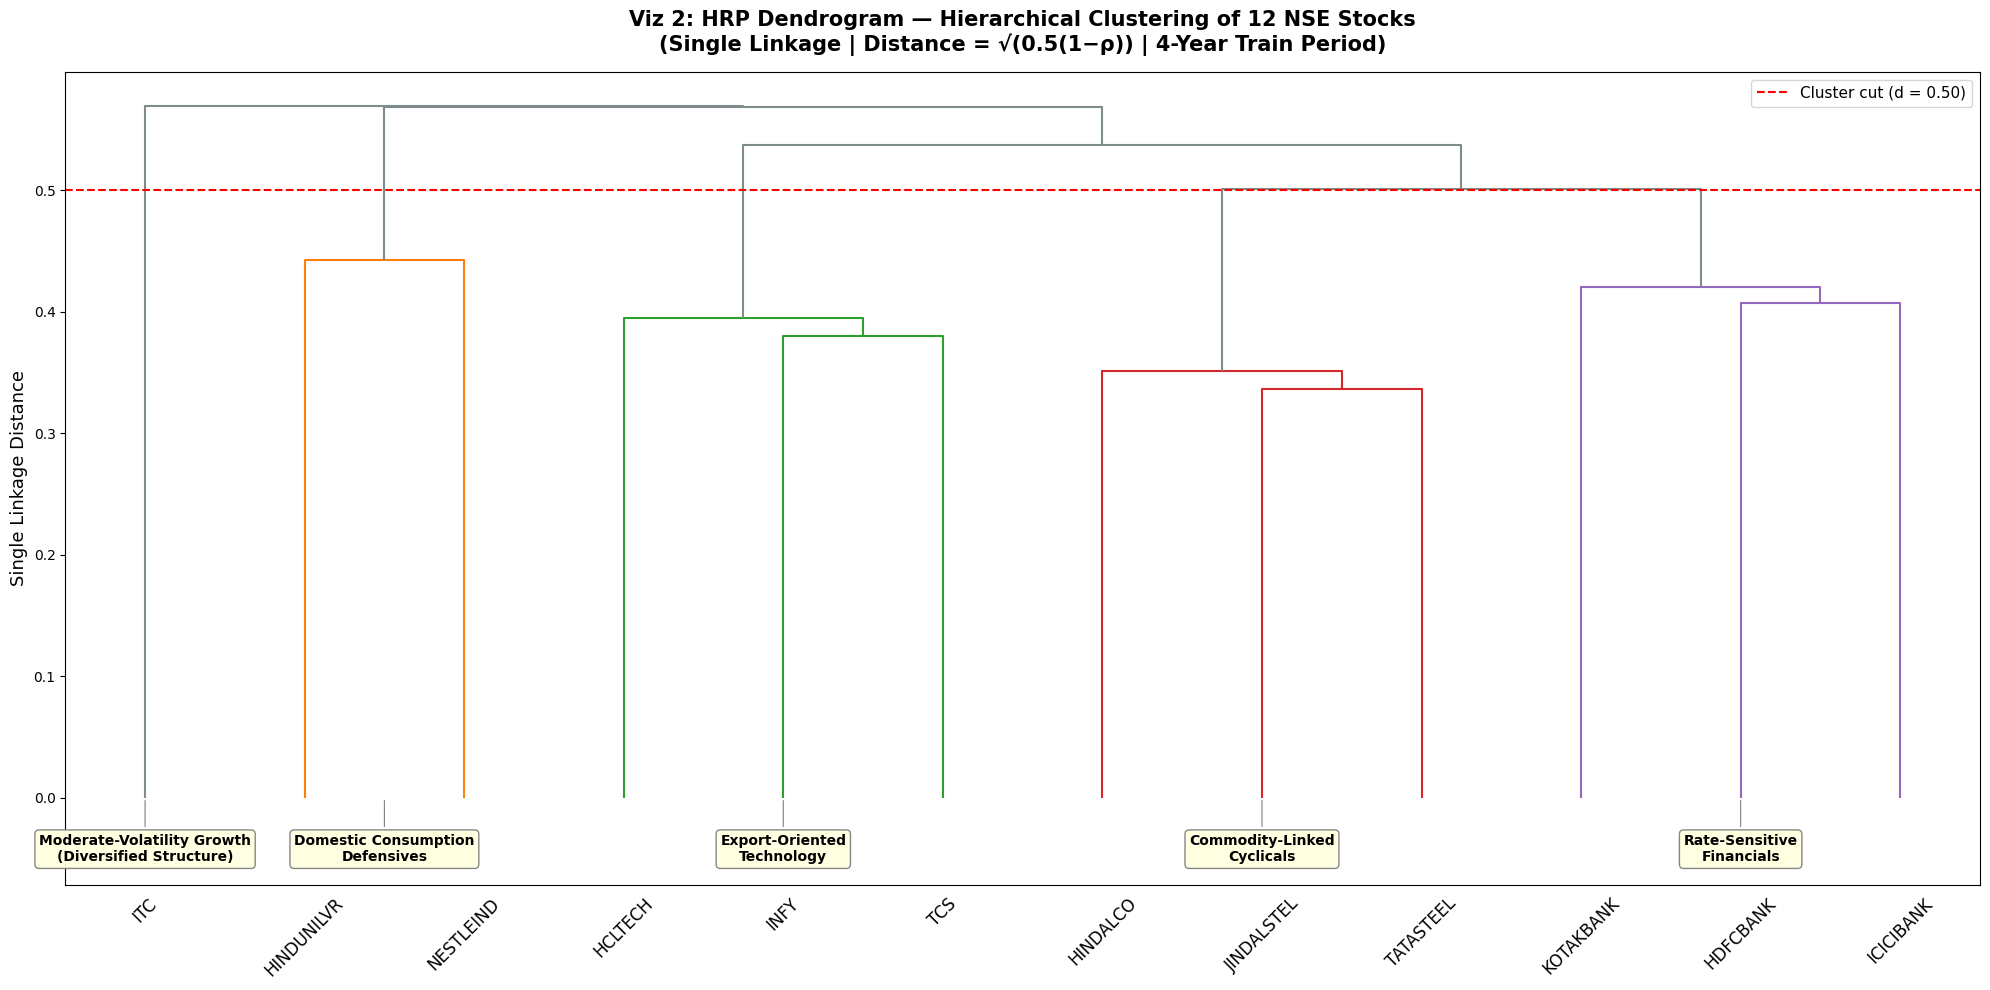

Saved: viz2_hrp_dendrogram_single_annotated.png


In [18]:
# Viz 2

distance_threshold_final = 0.5  # ≈ correlation 0.5

fig, ax = plt.subplots(figsize=(20, 10))

dendro = dendrogram(
    linkage_matrix,  # must be single linkage
    labels=stock_names,
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=12,
    color_threshold=distance_threshold_final,
    above_threshold_color='#7f8c8d'
)


ax.axhline(
    y=distance_threshold_final,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Cluster cut (d = {distance_threshold_final:.2f})'
)



leaf_positions = {
    label: x
    for label, x in zip(
        dendro['ivl'],
        ax.get_xticks()
    )
}


y_min, y_max = ax.get_ylim()
y_bracket = y_min - 0.05 * (y_max - y_min)

for c in sorted(cluster_assignment['Cluster'].unique()):
    members = cluster_assignment[
        cluster_assignment['Cluster'] == c
    ]['Stock'].tolist()
    
    member_xpos = [
        leaf_positions[m] for m in members if m in leaf_positions
    ]
    
    if member_xpos:
        x_center = np.mean(member_xpos)
        
        label_text = cluster_labels[c]
        
        ax.annotate(
            label_text,
            xy=(x_center, 0),
            xytext=(x_center, y_bracket),
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='top',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='lightyellow',
                edgecolor='gray',
                alpha=0.95
            ),
            arrowprops=dict(
                arrowstyle='-',
                color='gray',
                lw=0.8
            )
        )


ax.set_title(
    'Viz 2: HRP Dendrogram — Hierarchical Clustering of 12 NSE Stocks\n'
    '(Single Linkage | Distance = √(0.5(1−ρ)) | 4-Year Train Period)',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_ylabel('Single Linkage Distance', fontsize=13)
ax.set_xlabel('')
ax.legend(fontsize=11, loc='upper right')

ax.set_ylim(y_min - 0.12 * (y_max - y_min), y_max)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / 'viz2_hrp_dendrogram_single_annotated.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()

print('Saved: viz2_hrp_dendrogram_single_annotated.png')

---
## 7. Cluster Interpretation


In [19]:
# Detailed cluster interpretation
print('=' * 80)
print('CLUSTER INTERPRETATION')
print('=' * 80)

for c in sorted(cluster_assignment['Cluster'].unique()):
    members = cluster_assignment[cluster_assignment['Cluster'] == c]['Stock'].tolist()
    label = cluster_labels[c]
    
    # Statistics
    vols = returns_train[members].std() * np.sqrt(252)
    rets = returns_train[members].mean() * 252
    
    if len(members) > 1:
        intra_corr = corr_matrix.loc[members, members]
        mask_offdiag = ~np.eye(len(members), dtype=bool)
        avg_corr = intra_corr.values[mask_offdiag].mean()
    else:
        avg_corr = 1.0
    
    print(f'\nCluster {c}: "{label}"')
    print(f'  Members: {members}')
    print(f'  Avg Intra-cluster Correlation: {avg_corr:.3f}')
    print(f'  Annualized Volatility Range: {vols.min():.1%} – {vols.max():.1%}')
    print(f'  Annualized Return Range: {rets.min():.1%} – {rets.max():.1%}')
    
    # Interpretation
    print(f'  \n  Interpretation:')
    if 'Cyclical' in label or 'Commodity' in label:
        print(f'    These stocks exhibit high co-movement driven by shared sensitivity to')
        print(f'    global commodity prices and industrial demand cycles. Their elevated')
        print(f'    volatility ({vols.mean():.1%} avg) reflects the boom-bust nature of')
        print(f'    commodity-linked businesses, making them cluster tightly in risk space.')
    elif 'Financial' in label or 'Bank' in label or 'Rate' in label:
        print(f'    These stocks share a common interest-rate sensitivity and credit-cycle')
        print(f'    exposure. Their tight clustering (avg ρ = {avg_corr:.3f}) reflects the')
        print(f'    fact that monetary policy changes propagate similarly through all major')
        print(f'    private banks, creating correlated return patterns.')
    elif 'Tech' in label or 'Export' in label:
        print(f'    These stocks are linked by their revenue exposure to global IT spending')
        print(f'    and USD/INR dynamics. Their co-movement stems from shared sensitivity to')
        print(f'    global tech demand cycles and currency movements rather than domestic')
        print(f'    macro factors.')
    elif 'Defensive' in label or 'Consumption' in label:
        print(f'    These stocks exhibit lower volatility ({vols.mean():.1%} avg) and more')
        print(f'    stable return patterns. Their clustering reflects shared dependence on')
        print(f'    domestic consumption demand, which is less cyclical than industrial or')
        print(f'    export-driven revenue streams.')
    else:
        print(f'    This cluster groups stocks with similar risk-return profiles and')
        print(f'    co-movement patterns during the training period.')

print('\n' + '=' * 80)
print('Note: Clusters are labeled based on statistical co-movement patterns')
print('observed in the data, not pre-defined GICS sector classifications.')
print('=' * 80)

CLUSTER INTERPRETATION

Cluster 1: "Domestic Consumption
Defensives"
  Members: ['HINDUNILVR', 'NESTLEIND']
  Avg Intra-cluster Correlation: 0.608
  Annualized Volatility Range: 23.2% – 24.7%
  Annualized Return Range: 12.7% – 18.7%
  
  Interpretation:
    These stocks exhibit lower volatility (23.9% avg) and more
    stable return patterns. Their clustering reflects shared dependence on
    domestic consumption demand, which is less cyclical than industrial or
    export-driven revenue streams.

Cluster 2: "Export-Oriented
Technology"
  Members: ['HCLTECH', 'INFY', 'TCS']
  Avg Intra-cluster Correlation: 0.683
  Annualized Volatility Range: 25.2% – 29.0%
  Annualized Return Range: 19.4% – 31.7%
  
  Interpretation:
    These stocks are linked by their revenue exposure to global IT spending
    and USD/INR dynamics. Their co-movement stems from shared sensitivity to
    global tech demand cycles and currency movements rather than domestic
    macro factors.

Cluster 3: "Commodity-Link

---
## 8. Quasi-Diagonalized Covariance Matrix

Reorder the covariance matrix according to the cluster leaf order from the dendrogram; required for recursive bisection.

Quasi-Diagonalized Covariance Matrix (reordered by cluster leaf order):
Order: ['ITC', 'HINDUNILVR', 'NESTLEIND', 'HCLTECH', 'INFY', 'TCS', 'HINDALCO', 'JINDALSTEL', 'TATASTEEL', 'KOTAKBANK', 'HDFCBANK', 'ICICIBANK']


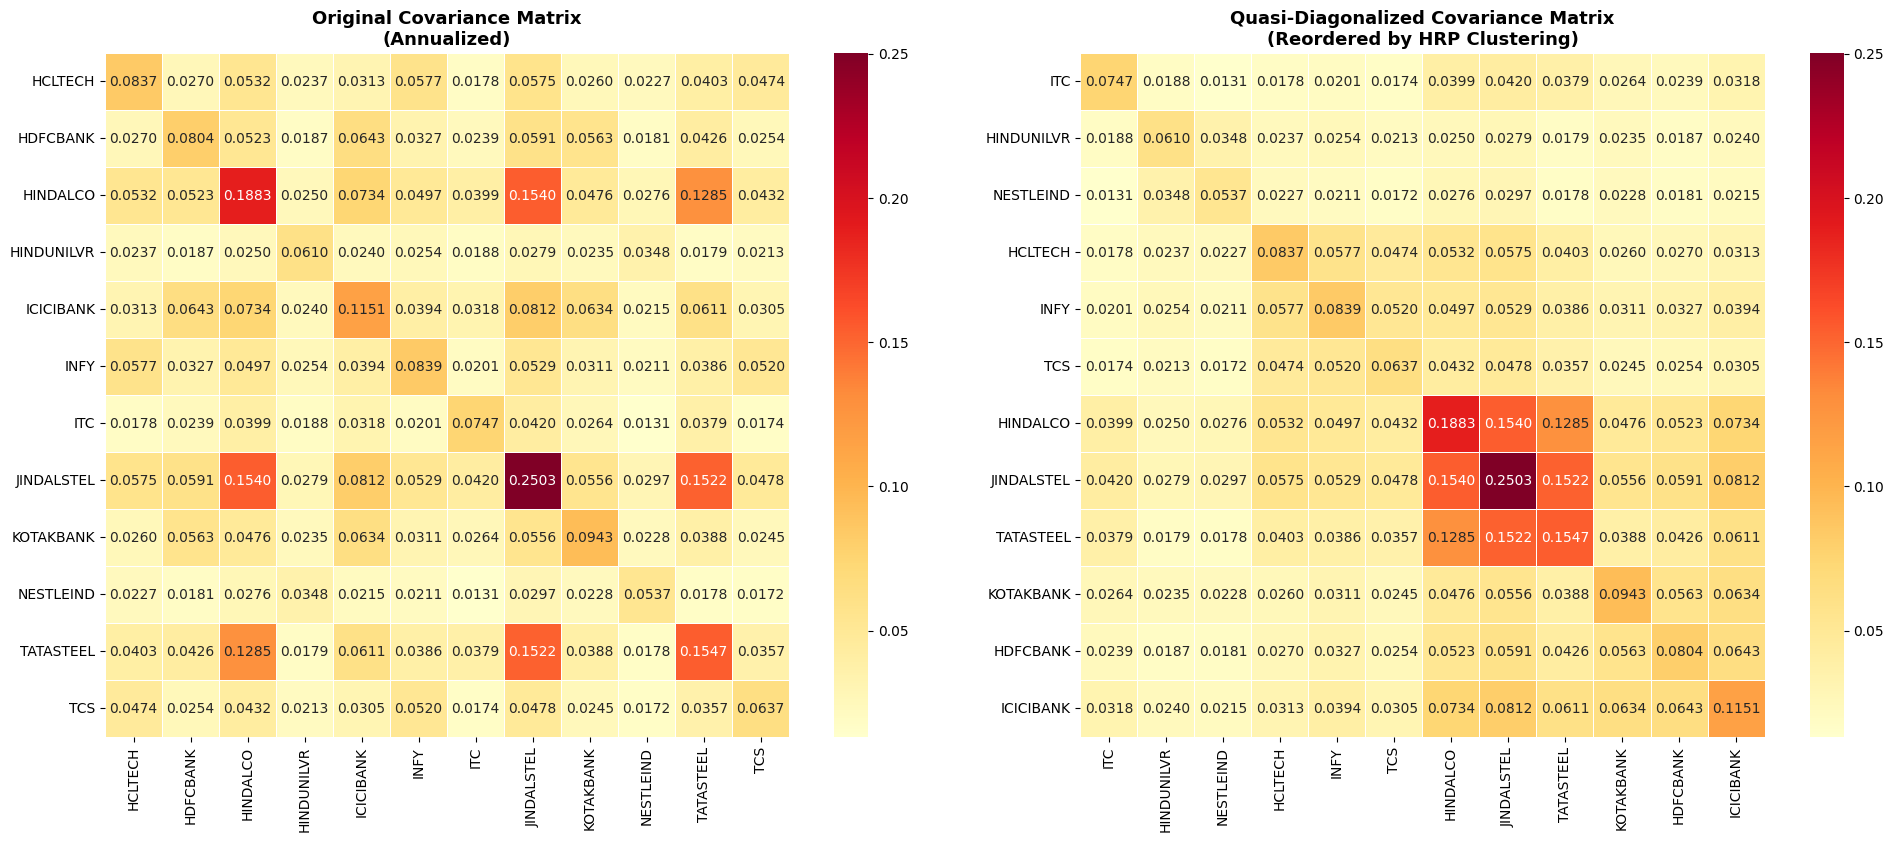

Saved: covariance_matrix_train.csv, covariance_quasi_diag.csv


In [20]:
# Compute the covariance matrix on train data
cov_matrix = returns_train.cov()

# Reorder according to leaf order (quasi-diagonalization)
sorted_stocks = [stock_names[i] for i in leaf_order]
cov_quasi_diag = cov_matrix.loc[sorted_stocks, sorted_stocks]

print('Quasi-Diagonalized Covariance Matrix (reordered by cluster leaf order):')
print(f'Order: {sorted_stocks}')

# Visualize: original vs quasi-diagonalized covariance
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Original order
sns.heatmap(cov_matrix * 252, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Original Covariance Matrix\n(Annualized)', fontsize=13, fontweight='bold')

# Quasi-diagonalized
sns.heatmap(cov_quasi_diag * 252, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Quasi-Diagonalized Covariance Matrix\n(Reordered by HRP Clustering)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quasi_diag_covariance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save for Person 4
cov_matrix.to_csv(DATA_PROCESSED / 'covariance_matrix_train.csv')
cov_quasi_diag.to_csv(DATA_PROCESSED / 'covariance_quasi_diag.csv')
print('Saved: covariance_matrix_train.csv, covariance_quasi_diag.csv')

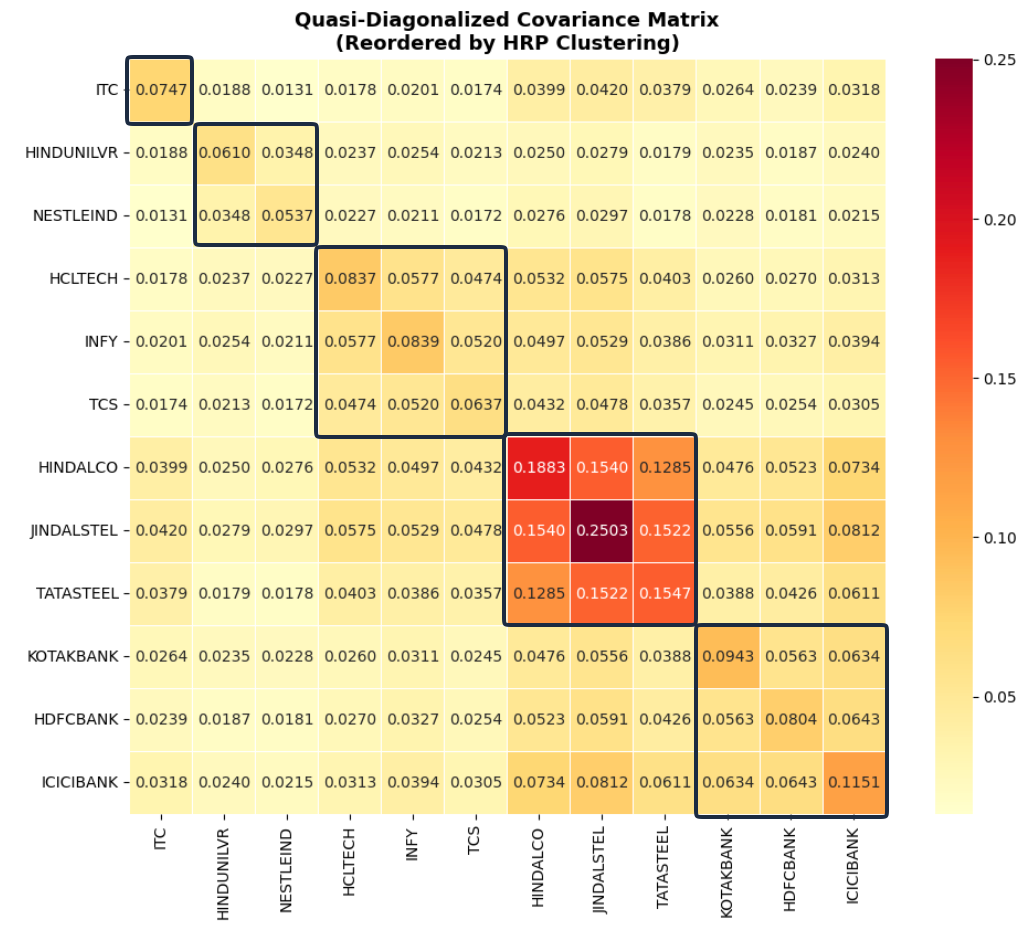

The quasi-diagonalized covariance matrix exhibits clear block structures corresponding to economically intuitive sectors. High covariance values are concentrated within clusters, while cross-cluster covariance is comparatively lower. This validates the hierarchical clustering structure and supports the suitability of HRP’s recursive risk allocation framework.

Metals and bank seem to form a block, but hierarchical clustering preserves their separation because intra-sector covariance remains stronger than inter-sector covariance.

---
## 9. Inter-Cluster Distance Analysis

Analyze merge distances to understand the tightness of relationships between clusters.

In [21]:
# Merge distance analysis
print('Linkage Matrix Merge Steps:')
print(f'{"Step":>4}  {"Cluster A":>10}  {"Cluster B":>10}  {"Distance":>10}  {"Size":>5}')
print('-' * 50)
for i, row in enumerate(linkage_matrix):
    clust_a = int(row[0])
    clust_b = int(row[1])
    dist = row[2]
    size = int(row[3])
    
    # Translate cluster indices to stock names
    def get_label(idx, n=len(stock_names)):
        if idx < n:
            return stock_names[int(idx)]
        else:
            return f'Merged-{int(idx)-n+1}'
    
    label_a = get_label(clust_a)
    label_b = get_label(clust_b)
    print(f'{i+1:>4}  {label_a:>10}  {label_b:>10}  {dist:>10.4f}  {size:>5}')

print('\nKey observations:')
print('- Early merges (low distance) indicate stocks with very similar risk profiles')
print('- Late merges (high distance) indicate structurally different risk regimes')
print('- The gap between merge distances helps identify natural cluster boundaries')

Linkage Matrix Merge Steps:
Step   Cluster A   Cluster B    Distance   Size
--------------------------------------------------
   1  JINDALSTEL   TATASTEEL      0.3364      2
   2    HINDALCO    Merged-1      0.3515      3
   3        INFY         TCS      0.3802      2
   4     HCLTECH    Merged-3      0.3947      3
   5    HDFCBANK   ICICIBANK      0.4071      2
   6   KOTAKBANK    Merged-5      0.4205      3
   7  HINDUNILVR   NESTLEIND      0.4425      2
   8    Merged-2    Merged-6      0.5007      6
   9    Merged-4    Merged-8      0.5367      9
  10    Merged-7    Merged-9      0.5680     11
  11         ITC   Merged-10      0.5688     12

Key observations:
- Early merges (low distance) indicate stocks with very similar risk profiles
- Late merges (high distance) indicate structurally different risk regimes
- The gap between merge distances helps identify natural cluster boundaries


---
## 10. Recursive bisection

In [22]:
# Load quasi-diagonalized covariance
cov_qd = pd.read_csv(DATA_PROCESSED / 'covariance_quasi_diag.csv', index_col=0)

# Get ordered asset list
leaf_order = pd.read_csv(DATA_PROCESSED / 'leaf_order.csv')['stock'].tolist()

In [23]:
def get_ivp(cov):
    """Compute inverse variance portfolio weights."""
    ivp = 1.0 / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

In [24]:
def get_cluster_variance(cov, cluster_items):
    """Compute variance of a cluster using IVP weights."""
    sub_cov = cov.loc[cluster_items, cluster_items].values
    w = get_ivp(sub_cov)
    cluster_var = w.T @ sub_cov @ w
    return cluster_var

In [26]:
def get_rec_bipart(cov, sort_ix):
    """
    Perform recursive bisection to compute HRP weights.

    cov: quasi-diagonalized covariance matrix (pandas DataFrame)
    sort_ix: ordered list of asset names (leaf order)
    """

    # Initialize all weights to 1
    w = pd.Series(1.0, index=sort_ix)

    # Initial cluster = all assets
    clusters = [sort_ix]
    print(f"inital clusters:\n{clusters}")
    while len(clusters) > 0:

        print(f"weights:\n{w.to_list()}\n")
        # Bisect clusters at this level
        new_clusters = []
        for cluster in clusters:
            if len(cluster) > 1:
                split = int(len(cluster) / 2)
                new_clusters.append(cluster[:split])
                new_clusters.append(cluster[split:])

        # Replace clusters with newly split ones
        clusters = new_clusters
        print(f"clusters after split:\n{clusters}")

        # Allocate weights between cluster pairs
        for i in range(0, len(clusters), 2):

            c1 = clusters[i]
            c2 = clusters[i + 1]

            var1 = get_cluster_variance(cov, c1)
            var2 = get_cluster_variance(cov, c2)

            alpha = 1.0 - var1 / (var1 + var2)

            w[c1] *= alpha
            w[c2] *= (1.0 - alpha)

    return w

In [27]:
# Compute HRP weights
hrp_weights = get_rec_bipart(cov_qd, leaf_order)

# Normalize (safety)
hrp_weights /= hrp_weights.sum()

print("HRP Weights:")
print(hrp_weights.sort_values(ascending=False))

inital clusters:
[['ITC', 'HINDUNILVR', 'NESTLEIND', 'HCLTECH', 'INFY', 'TCS', 'HINDALCO', 'JINDALSTEL', 'TATASTEEL', 'KOTAKBANK', 'HDFCBANK', 'ICICIBANK']]
weights:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

clusters after split:
[['ITC', 'HINDUNILVR', 'NESTLEIND', 'HCLTECH', 'INFY', 'TCS'], ['HINDALCO', 'JINDALSTEL', 'TATASTEEL', 'KOTAKBANK', 'HDFCBANK', 'ICICIBANK']]
weights:
[0.6883993761762321, 0.6883993761762321, 0.6883993761762321, 0.6883993761762321, 0.6883993761762321, 0.6883993761762321, 0.31160062382376785, 0.31160062382376785, 0.31160062382376785, 0.31160062382376785, 0.31160062382376785, 0.31160062382376785]

clusters after split:
[['ITC', 'HINDUNILVR', 'NESTLEIND'], ['HCLTECH', 'INFY', 'TCS'], ['HINDALCO', 'JINDALSTEL', 'TATASTEEL'], ['KOTAKBANK', 'HDFCBANK', 'ICICIBANK']]
weights:
[0.42878159189178067, 0.42878159189178067, 0.42878159189178067, 0.2596177842844515, 0.2596177842844515, 0.2596177842844515, 0.09774754989854027, 0.09774754989854027, 0.097747

The recursive bisection output shows that HRP is allocating capital in a structurally intuitive and risk-aware manner. At the top level, the algorithm assigns greater weight to the defensive and lower-volatility cluster (FMCG and parts of IT) while penalizing the higher-volatility cyclical cluster (metals and, to a lesser extent, banks). Within each sectoral block, weights are further distributed inversely to individual asset variance, leading to higher allocations for relatively stable stocks such as HINDUNILVR and NESTLEIND, and smaller allocations for more volatile names like JINDALSTEL and TATASTEEL. Overall, the portfolio reflects hierarchical diversification: risk is balanced first across major economic regimes and then within sectors, producing an economically coherent and naturally defensive allocation without relying on return forecasts or full covariance inversion.


## 11. Performance on test set

In [28]:
daily_returns_test = pd.read_csv(DATA_PROCESSED / 'daily_returns_test.csv', index_col=0)

In [29]:
hrp_weights.to_dict()

{'ITC': 0.1632465026457766,
 'HINDUNILVR': 0.12434058656291219,
 'NESTLEIND': 0.14119450268309192,
 'HCLTECH': 0.11015121741400082,
 'INFY': 0.06448249130722031,
 'TCS': 0.08498407556323034,
 'HINDALCO': 0.0460140415476402,
 'JINDALSTEL': 0.01976423783016205,
 'TATASTEEL': 0.03196927052073802,
 'KOTAKBANK': 0.09715922359035094,
 'HDFCBANK': 0.06870463549933992,
 'ICICIBANK': 0.047989214835536746}

In [30]:
hrp_weights

ITC           0.163247
HINDUNILVR    0.124341
NESTLEIND     0.141195
HCLTECH       0.110151
INFY          0.064482
TCS           0.084984
HINDALCO      0.046014
JINDALSTEL    0.019764
TATASTEEL     0.031969
KOTAKBANK     0.097159
HDFCBANK      0.068705
ICICIBANK     0.047989
dtype: float64

In [40]:
# let us quickly generate MPT weights for the daily returns over 4 years
# let us find the weights that maximize the portfolio sharpe ratio

from scipy.optimize import minimize

def compute_mpt_weights(daily_returns: pd.DataFrame,
                        rf_annual: float = 0.065,
                        trading_days: int = 252) -> pd.Series:
    """
    Compute Maximum Sharpe Ratio portfolio weights (long-only).

    Parameters
    ----------
    daily_returns : pd.DataFrame
        Daily percentage returns (assets as columns).
    rf_annual     : float
        Annual risk-free rate (default 6.5% for India).
    trading_days  : int
        Trading days per year (default 252).

    Returns
    -------
    pd.Series
        Normalized long-only weights that maximize the Sharpe ratio.
    """

    rf_daily = rf_annual / trading_days
    n        = daily_returns.shape[1]
    mu       = daily_returns.mean().values          # expected daily returns
    cov      = daily_returns.cov().values            # sample covariance

    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ cov @ w)
        return -(port_ret - rf_daily) / port_vol     # negative because we minimize

    # Constraints & bounds
    constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}  # weights sum to 1
    bounds      = [(0, 1) for _ in range(n)]                     # long-only: w >= 0

    # Multiple random starting points (avoids local minima)
    best_result = None
    best_sharpe = -np.inf

    np.random.seed(42)
    for _ in range(50):
        w0     = np.random.dirichlet(np.ones(n))     # random valid starting weights
        result = minimize(neg_sharpe, w0,
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 1000, 'ftol': 1e-12})

        if result.success and (-result.fun) > best_sharpe:
            best_sharpe = -result.fun
            best_result = result

    if best_result is None:
        raise RuntimeError("Optimization failed across all starting points.")

    weights = pd.Series(best_result.x, index=daily_returns.columns)
    weights = weights / weights.sum()                # normalize for safety

    port_ret_ann = (weights.values @ mu) * trading_days
    port_vol_ann = np.sqrt(weights.values @ cov @ weights.values) * np.sqrt(trading_days)
    sharpe_ann   = (port_ret_ann - rf_annual) / port_vol_ann

    print("=" * 50)
    print("MPT LONG-ONLY MAX SHARPE — RESULTS")
    print("=" * 50)
    print(f"  Annualized Return : {port_ret_ann*100:.2f}%")
    print(f"  Annualized Vol    : {port_vol_ann*100:.2f}%")
    print(f"  Sharpe Ratio      : {sharpe_ann:.4f}")
    print(f"  Sum of weights    : {weights.sum():.6f}")
    print(f"  All positive      : {(weights >= -1e-8).all()}")
    print()
    print("Weights:")
    print("-" * 35)
    for ticker, w in weights.sort_values(ascending=False).items():
        print(f"  {ticker:<14} {w:.4f}")

    return weights

daily_returns_train = pd.read_csv(DATA_PROCESSED / "daily_returns_train.csv",
                                      index_col=0, parse_dates=True)

mpt_weights = compute_mpt_weights(daily_returns_train)

MPT LONG-ONLY MAX SHARPE — RESULTS
  Annualized Return : 32.21%
  Annualized Vol    : 22.73%
  Sharpe Ratio      : 1.1310
  Sum of weights    : 1.000000
  All positive      : True

Weights:
-----------------------------------
  HCLTECH        0.3610
  ITC            0.2680
  JINDALSTEL     0.1608
  NESTLEIND      0.1206
  TATASTEEL      0.0896
  HINDUNILVR     0.0000
  HINDALCO       0.0000
  KOTAKBANK      0.0000
  INFY           0.0000
  TCS            0.0000
  HDFCBANK       0.0000
  ICICIBANK      0.0000


In [75]:
mpt_weights.to_dict()

{'HCLTECH': 0.3609999821312001,
 'HDFCBANK': 0.0,
 'HINDALCO': 2.0220005220811246e-17,
 'HINDUNILVR': 2.0794688918393905e-17,
 'ICICIBANK': 0.0,
 'INFY': 1.0825793873413342e-17,
 'ITC': 0.26802427715149574,
 'JINDALSTEL': 0.1607871209555185,
 'KOTAKBANK': 1.3742209588753508e-17,
 'NESTLEIND': 0.12060858625429907,
 'TATASTEEL': 0.08958003350748653,
 'TCS': 1.6826247833020952e-18}

In [ ]:
# mpt_weights = pd.Series({
#     'TCS':        0.2753,
#     'INFY':      -0.3813,
#     'HCLTECH':   -0.0260,
#     'TATASTEEL':  0.1054,
#     'HINDALCO':   0.1295,
#     'JINDALSTEL': -0.0060,
#     'HDFCBANK':   0.2820,
#     'ICICIBANK':  0.3276,
#     'KOTAKBANK':  -0.3032,
#     'HINDUNILVR': 0.4300,
#     'ITC':        0.0727,
#     'NESTLEIND':  0.0940,
# })

In [43]:
print(daily_returns_test[hrp_weights.index].values.shape, hrp_weights.shape)
hrp_daily_ret = (daily_returns_test[hrp_weights.index] @ hrp_weights)
hrp_daily_ret.shape

(246, 12) (12,)


(246,)

In [44]:
print(daily_returns_test[mpt_weights.index].values.shape, mpt_weights.shape)
mpt_daily_ret = (daily_returns_test[mpt_weights.index] @ mpt_weights)
mpt_daily_ret.shape

(246, 12) (12,)


(246,)

In [45]:

TRADING_DAYS = 252
RF_ANNUAL    = 0.05        # India 10Y ~6.5%
rf_daily     = RF_ANNUAL / TRADING_DAYS

def compute_metrics(port_returns, label="Portfolio"):
    n = len(port_returns)

    cum_return  = (1 + port_returns).prod() - 1
    ann_return  = (1 + cum_return) ** (TRADING_DAYS / n) - 1
    ann_vol     = port_returns.std() * np.sqrt(TRADING_DAYS)

    excess = port_returns - rf_daily
    sharpe = (excess.mean() / excess.std()) * np.sqrt(TRADING_DAYS)

    cum_wealth  = (1 + port_returns).cumprod()
    rolling_max = cum_wealth.cummax()
    drawdown    = (cum_wealth - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    metrics = {
        "Cumulative Return"    : f"{cum_return * 100:.2f}%",
        "Annualized Return"    : f"{ann_return * 100:.2f}%",
        "Annualized Volatility": f"{ann_vol * 100:.2f}%",
        "Sharpe Ratio"         : f"{sharpe:.4f}",
        "Maximum Drawdown"     : f"{max_dd * 100:.2f}%",
    }
    return metrics, cum_wealth, drawdown


In [46]:
hrp_metrics, hrp_cum_wealth, hrp_drawdown = compute_metrics(
    hrp_daily_ret, label="HRP"
)
mpt_metrics, mpt_cum_wealth, mpt_drawdown = compute_metrics(
    mpt_daily_ret, label="MPT"
)

In [47]:
hrp_metrics

{'Cumulative Return': '5.97%',
 'Annualized Return': '6.12%',
 'Annualized Volatility': '12.13%',
 'Sharpe Ratio': '0.1379',
 'Maximum Drawdown': '-10.11%'}

In [48]:
mpt_metrics

{'Cumulative Return': '17.30%',
 'Annualized Return': '17.75%',
 'Annualized Volatility': '15.03%',
 'Sharpe Ratio': '0.8298',
 'Maximum Drawdown': '-8.94%'}

In [49]:
# monthly rebalance, and turn-over

def backtest_monthly_rebalance(returns, target_weights):
    """
    Monthly rebalanced backtest with turnover calculation.
    
    returns: DataFrame (daily pct returns, test year)
    target_weights: Series (train-based weights)
    """

    returns = returns.copy()
    weights = target_weights.copy()
    
    portfolio_returns = []
    turnover_series = []
    
    # Identify rebalance dates (first trading day of each month)
    rebalance_dates = returns.resample('ME').first().index
    rebalance_dates = returns.index.intersection(rebalance_dates)

    prev_weights = weights.copy()

    for date in returns.index:

        # Rebalance
        if date in rebalance_dates:
            
            # Compute turnover BEFORE resetting
            turnover = np.abs(weights - prev_weights).sum()
            turnover_series.append(turnover)

            # Reset to target weights
            weights = target_weights.copy()
            prev_weights = weights.copy()

        else:
            turnover_series.append(0.0)

        # Compute portfolio return
        daily_ret = np.dot(weights, returns.loc[date])
        portfolio_returns.append(daily_ret)

        # Let weights drift
        weights = weights * (1 + returns.loc[date])
        weights = weights / weights.sum()

    portfolio_returns = pd.Series(portfolio_returns, index=returns.index)
    turnover_series = pd.Series(turnover_series, index=returns.index)

    return portfolio_returns, turnover_series

In [50]:
hrp_test_ret, hrp_turnover = backtest_monthly_rebalance(
    returns_test, hrp_weights
)

mpt_test_ret, mpt_turnover = backtest_monthly_rebalance(
    returns_test, mpt_weights
)

In [52]:
hrp_monthly_turnover = hrp_turnover.resample('ME').sum()
mpt_monthly_turnover = mpt_turnover.resample('ME').sum()

turnover_summary = pd.DataFrame({
    "HRP": hrp_monthly_turnover.mean(),
    "MPT": mpt_monthly_turnover.mean()
}, index=["Average Monthly Turnover"])

turnover_summary

,HRP,MPT
Average Monthly Turnover,0.035671,0.039527


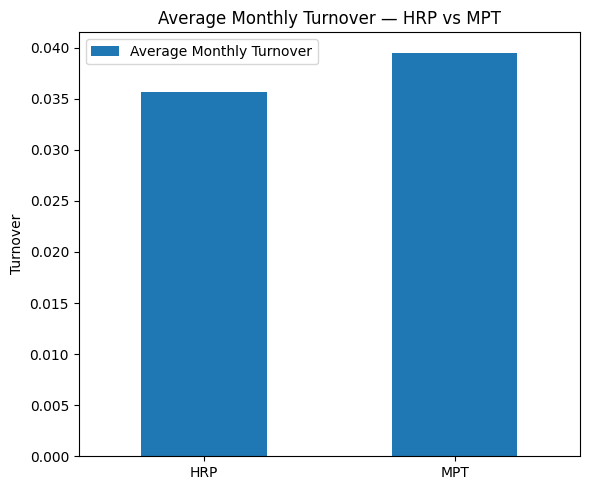

In [53]:
turnover_summary.T.plot(kind="bar", figsize=(6,5))

plt.title("Average Monthly Turnover — HRP vs MPT")
plt.ylabel("Turnover")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
hrp_metrics

{'Cumulative Return': '5.97%',
 'Annualized Return': '6.12%',
 'Annualized Volatility': '12.13%',
 'Sharpe Ratio': '0.1379',
 'Maximum Drawdown': '-10.11%'}

In [56]:
mpt_metrics

{'Cumulative Return': '17.30%',
 'Annualized Return': '17.75%',
 'Annualized Volatility': '15.03%',
 'Sharpe Ratio': '0.8298',
 'Maximum Drawdown': '-8.94%'}

In [65]:

final_comparison = pd.DataFrame({
    "Annual Return": [hrp_metrics['Annualized Return'], mpt_metrics['Annualized Return']],
    "Annual Volatility": [hrp_metrics['Annualized Volatility'], mpt_metrics['Annualized Volatility']],
    "Sharpe": [hrp_metrics['Sharpe Ratio'], mpt_metrics['Sharpe Ratio']],
    "Max Drawdown": [hrp_metrics['Maximum Drawdown'], mpt_metrics['Maximum Drawdown']],
    "Avg Monthly Turnover": [hrp_monthly_turnover.mean(), mpt_monthly_turnover.mean()]
}, index=["HRP", "MPT"])

final_comparison

,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Avg Monthly Turnover
HRP,6.12%,12.13%,0.1379,-10.11%,0.035671
MPT,17.75%,15.03%,0.8298,-8.94%,0.039527


In [60]:
def backtest_with_weight_tracking(returns, target_weights):
    
    returns = returns.copy()
    weights = target_weights.copy()
    
    portfolio_returns = []
    weight_history = []

    rebalance_dates = returns.resample('ME').first().index
    rebalance_dates = returns.index.intersection(rebalance_dates)

    for date in returns.index:
        
        if date in rebalance_dates:
            weights = target_weights.copy()

        # Store weights
        weight_history.append(weights.copy())

        # Portfolio return
        daily_ret = np.dot(weights, returns.loc[date])
        portfolio_returns.append(daily_ret)

        # Drift weights
        weights = weights * (1 + returns.loc[date])
        weights = weights / weights.sum()

    portfolio_returns = pd.Series(portfolio_returns, index=returns.index)
    weight_history = pd.DataFrame(weight_history, index=returns.index)

    return portfolio_returns, weight_history

In [61]:
hrp_ret, hrp_weight_path = backtest_with_weight_tracking(
    returns_test, hrp_weights
)

mpt_ret, mpt_weight_path = backtest_with_weight_tracking(
    returns_test, mpt_weights
)

In [72]:
hrp_weight_path.to_csv("hrp_wt_trajectory.csv")
mpt_weight_path.to_csv("mpt_wt_trajectory.csv")

In [73]:
daily_returns_test.index[0], daily_returns_test.index[-1]

('2024-01-01', '2024-12-31')

In [74]:
daily_returns_train.index[0], daily_returns_train.index[-1]

(Timestamp('2020-01-02 00:00:00'), Timestamp('2023-12-29 00:00:00'))

In [71]:
mpt_weight_path

,HCLTECH,HDFCBANK,HINDALCO,HINDUNILVR,ICICIBANK,INFY,ITC,JINDALSTEL,KOTAKBANK,NESTLEIND,TATASTEEL,TCS
Date,,,,,,,,,,,,
2024-01-01,0.361000,0.0,2.022001e-17,2.079469e-17,0.0,1.082579e-17,0.268024,0.160787,1.374221e-17,0.120609,0.089580,1.682625e-18
2024-01-02,0.361489,0.0,1.986173e-17,2.050409e-17,0.0,1.077016e-17,0.268609,0.158218,1.360460e-17,0.122891,0.088793,1.672628e-18
2024-01-03,0.359156,0.0,2.013969e-17,2.025137e-17,0.0,1.068602e-17,0.270779,0.158545,1.333219e-17,0.122606,0.088913,1.665611e-18
2024-01-04,0.355488,0.0,1.958401e-17,2.043105e-17,0.0,1.049800e-17,0.277960,0.157980,1.349404e-17,0.121359,0.087213,1.644330e-18
2024-01-05,0.351304,0.0,1.951185e-17,2.033387e-17,0.0,1.066452e-17,0.277636,0.160874,1.348573e-17,0.123628,0.086558,1.634227e-18
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.375100,0.0,1.870113e-17,1.933486e-17,0.0,1.160617e-17,0.259627,0.165260,1.388274e-17,0.114458,0.085556,1.719822e-18
2024-12-26,0.373369,0.0,1.847692e-17,1.927939e-17,0.0,1.149763e-17,0.261549,0.165356,1.389215e-17,0.115095,0.084631,1.726104e-18
2024-12-27,0.374572,0.0,1.853769e-17,1.927967e-17,0.0,1.150164e-17,0.261046,0.165320,1.393885e-17,0.114342,0.084721,1.723900e-18


In [62]:
selected = ["HDFCBANK", "ICICIBANK", "KOTAKBANK"]

In [145]:
# Weight Sensitivity Plot

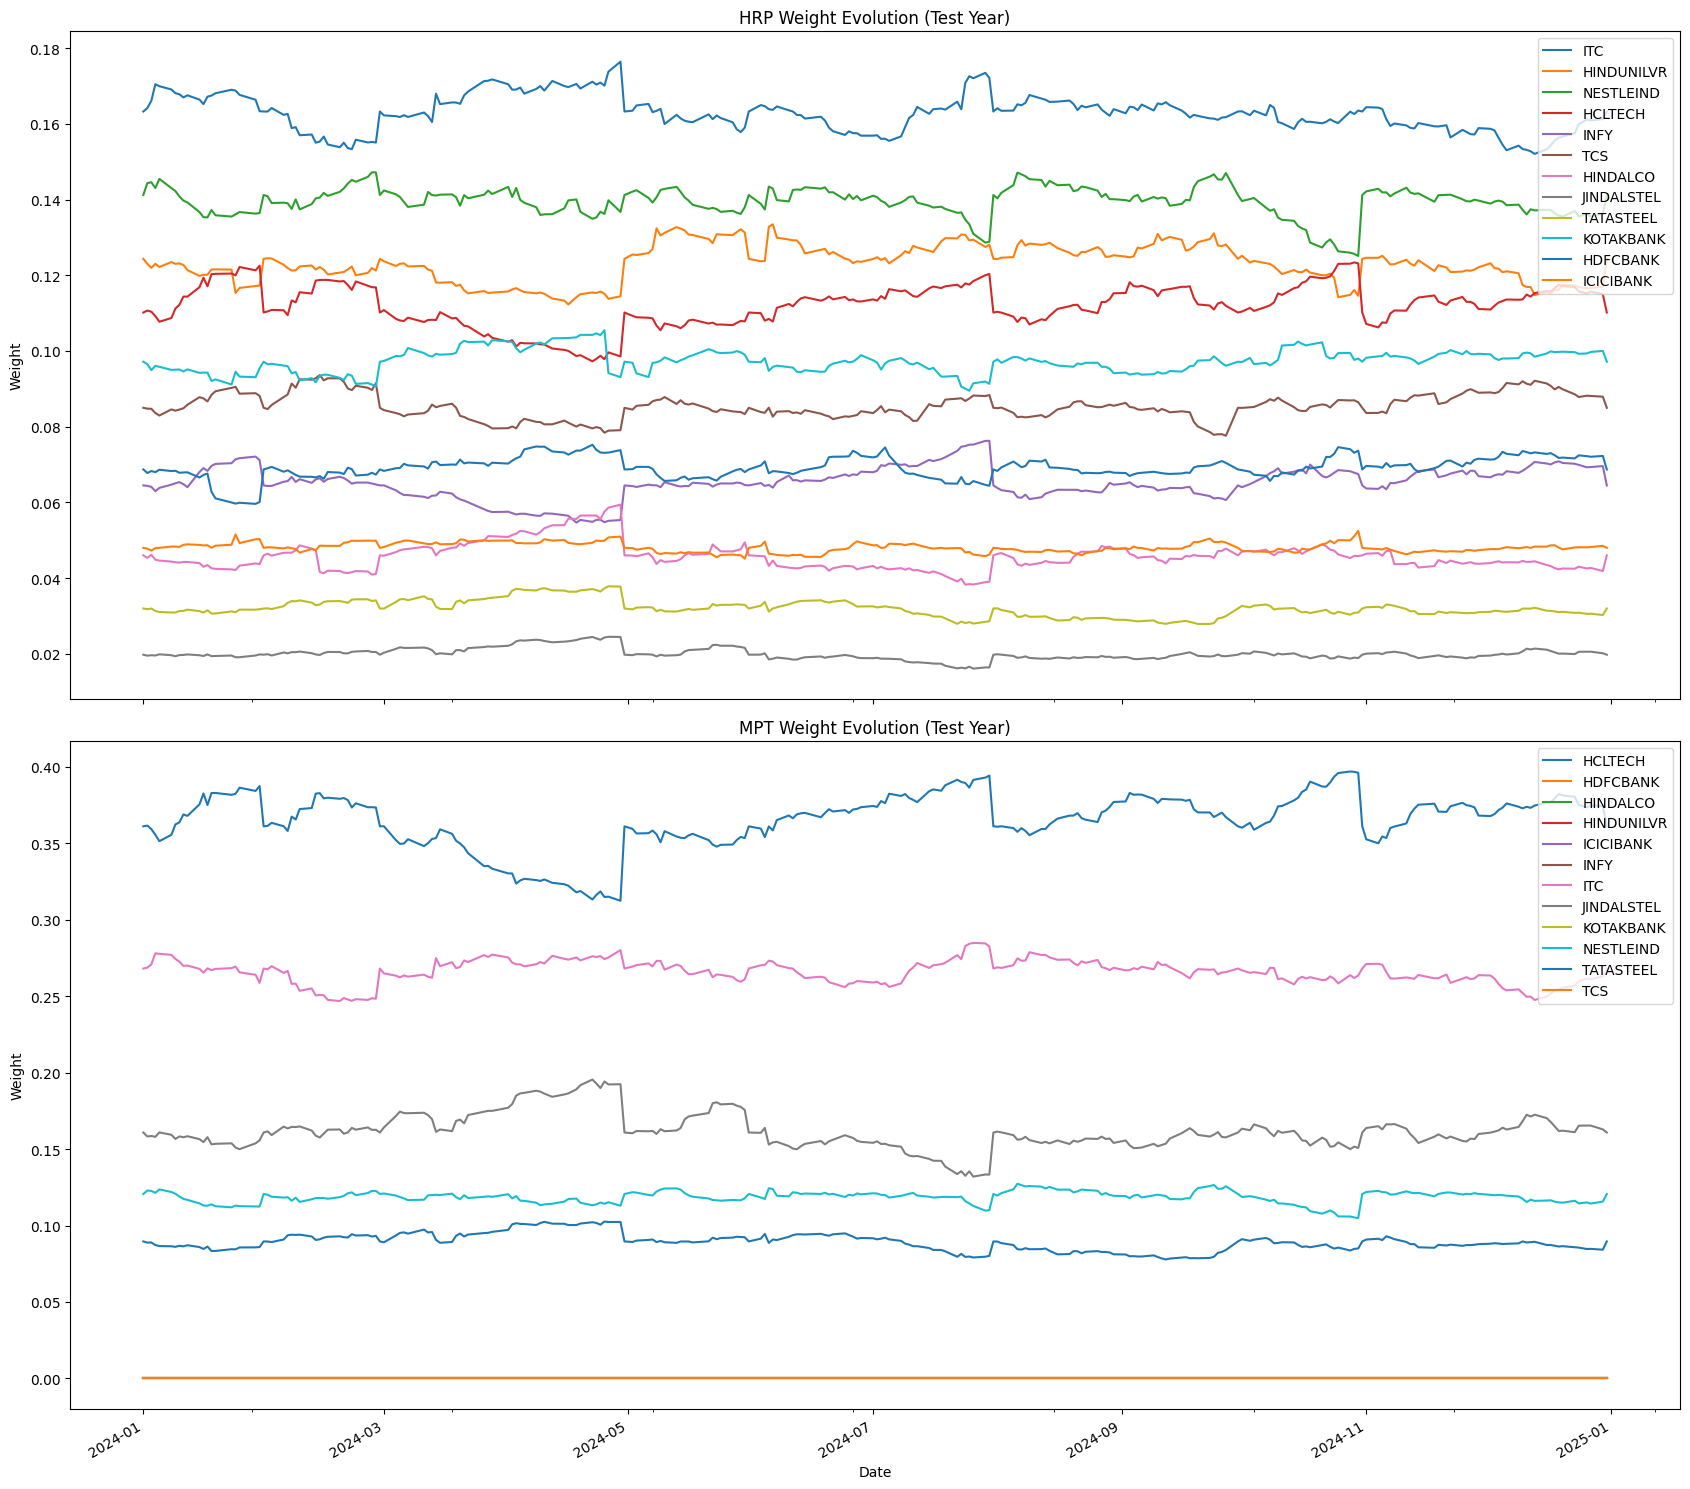

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(17,15), sharex=True)

# HRP
hrp_weight_path[:].plot(ax=axes[0])
axes[0].set_title("HRP Weight Evolution (Test Year)")
axes[0].set_ylabel("Weight")

# MPT
mpt_weight_path[:].plot(ax=axes[1])
axes[1].set_title("MPT Weight Evolution (Test Year)")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()